In [1]:
# Week 3 - Unsupervised Learning and Clustering Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


In [4]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [6]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

cluster_data = df[features].copy()

print("Selected features:")
print(cluster_data.head())

Selected features:
   pclass   age  sibsp  parch     fare
0       3  22.0      1      0   7.2500
1       1  38.0      1      0  71.2833
2       3  26.0      0      0   7.9250
3       1  35.0      1      0  53.1000
4       3  35.0      0      0   8.0500


In [10]:
cluster_data["age"] = cluster_data["age"].fillna(cluster_data["age"].median())

print("Missing values after preprocessing:")
print(cluster_data.isnull().sum())

Missing values after preprocessing:
pclass    0
age       0
sibsp     0
parch     0
fare      0
dtype: int64


In [11]:
print("Shape of clustering data:", cluster_data.shape)

print("\nSummary statistics:")
display(cluster_data.describe())

Shape of clustering data: (891, 5)

Summary statistics:


,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,35.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features
)

print("Standardized data:")
display(scaled_df.head())

Standardized data:


,pclass,age,sibsp,parch,fare
0,0.827377,-0.565736,0.432793,-0.473674,-0.502445
1,-1.566107,0.663861,0.432793,-0.473674,0.786845
2,0.827377,-0.258337,-0.474545,-0.473674,-0.488854
3,-1.566107,0.433312,0.432793,-0.473674,0.420730
4,0.827377,0.433312,-0.474545,-0.473674,-0.486337


In [15]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

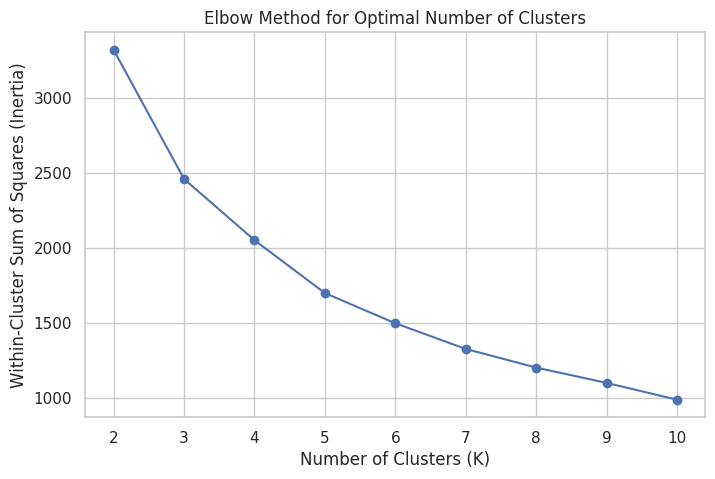

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")

plt.show()

In [17]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

results = pd.DataFrame({
    "Number of Clusters": list(K_range),
    "Silhouette Score": silhouette_scores
})

display(results)

,Number of Clusters,Silhouette Score
0,2,0.375760
1,3,0.417016
2,4,0.413555
3,5,0.428949
4,6,0.428131
5,7,0.401198
6,8,0.405833
7,9,0.370341
8,10,0.380772


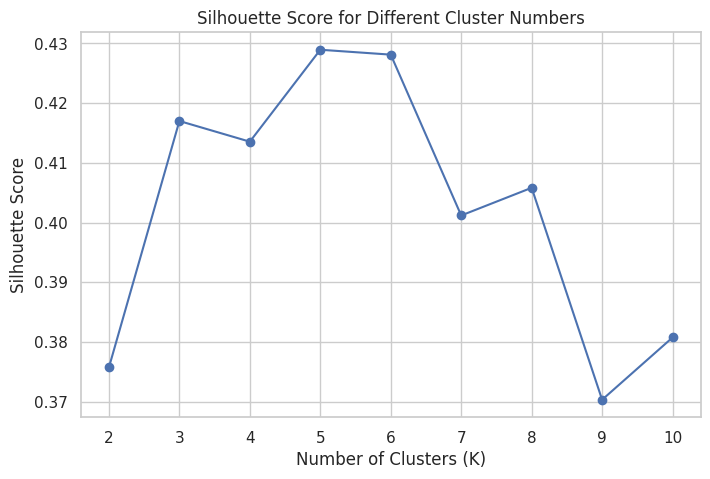

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different Cluster Numbers")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.show()

In [19]:
optimal_k = 3

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 3


In [20]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_data)

print("K-Means clustering completed successfully!")
print("Cluster labels:")
print(cluster_labels[:20])

K-Means clustering completed successfully!
Cluster labels:
[1 2 1 2 1 1 2 0 1 1 0 2 1 0 1 2 0 1 1 1]


In [21]:
df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

print("Clustered dataset:")
display(df_clustered.head())

Clustered dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Cluster
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


In [22]:
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

print("Number of passengers in each cluster:")
print(cluster_counts)

Number of passengers in each cluster:
Cluster
0    110
1    542
2    239
Name: count, dtype: int64


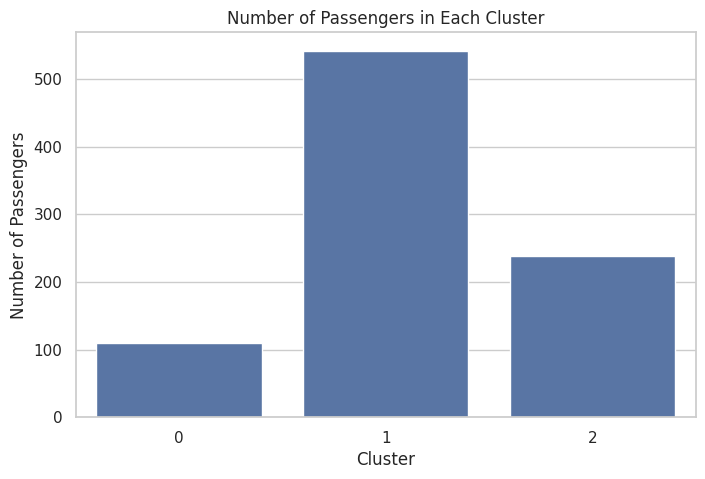

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clustered,
    x="Cluster"
)

plt.title("Number of Passengers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Passengers")

plt.show()

In [24]:
cluster_summary = df_clustered.groupby("Cluster")[features].mean()

print("Average characteristics of each cluster:")
display(cluster_summary)

Average characteristics of each cluster:


,pclass,age,sibsp,parch,fare
Cluster,,,,,
0,2.572727,13.358247,2.336364,1.936364,45.921856
1,2.771218,27.719167,0.225092,0.110701,12.191819
2,1.138075,41.148325,0.364017,0.280335,71.274390


In [25]:
cluster_summary = df_clustered.groupby("Cluster").agg({
    "pclass": "mean",
    "age": "mean",
    "sibsp": "mean",
    "parch": "mean",
    "fare": "mean"
})

display(cluster_summary)

,pclass,age,sibsp,parch,fare
Cluster,,,,,
0,2.572727,13.358247,2.336364,1.936364,45.921856
1,2.771218,27.719167,0.225092,0.110701,12.191819
2,1.138075,41.148325,0.364017,0.280335,71.274390


In [26]:
survival_by_cluster = df_clustered.groupby("Cluster")["survived"].mean()

print("Survival rate by cluster:")
print(survival_by_cluster)

Survival rate by cluster:
Cluster
0    0.454545
1    0.284133
2    0.577406
Name: survived, dtype: float64


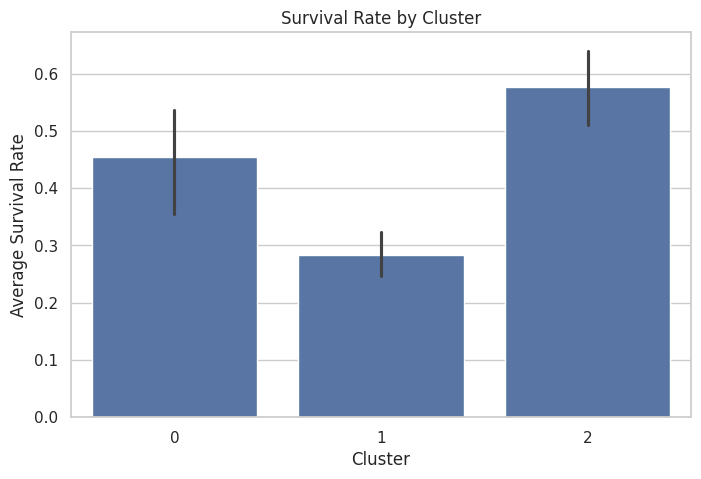

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clustered,
    x="Cluster",
    y="survived",
    estimator="mean"
)

plt.title("Survival Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Survival Rate")

plt.show()

In [28]:
gender_cluster = pd.crosstab(
    df_clustered["Cluster"],
    df_clustered["sex"],
    normalize="index"
) * 100

print("Gender distribution within each cluster (%):")
display(gender_cluster)

Gender distribution within each cluster (%):


sex,female,male
Cluster,,
0,54.545455,45.454545
1,28.597786,71.402214
2,41.422594,58.577406


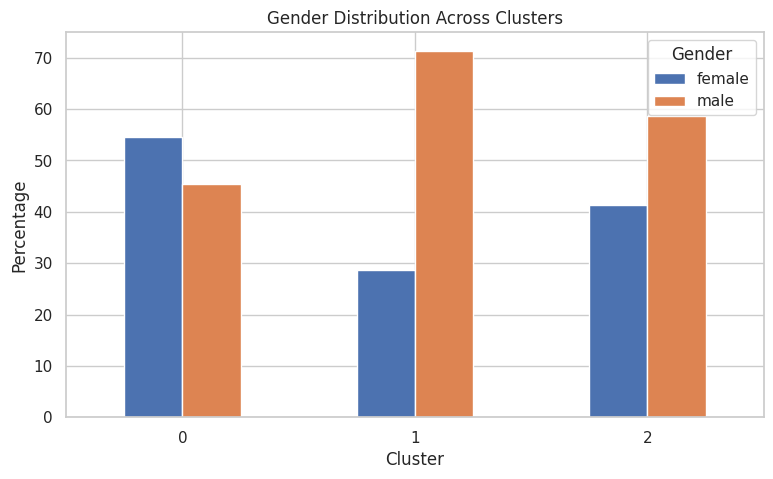

In [29]:
gender_cluster.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Gender Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.legend(title="Gender")

plt.xticks(rotation=0)

plt.show()

In [30]:
class_cluster = pd.crosstab(
    df_clustered["Cluster"],
    df_clustered["pclass"],
    normalize="index"
) * 100

print("Passenger class distribution within each cluster (%):")
display(class_cluster)

Passenger class distribution within each cluster (%):


pclass,1,2,3
Cluster,,,
0,9.090909,24.545455,66.363636
1,0.000000,22.878229,77.121771
2,86.192469,13.807531,0.000000


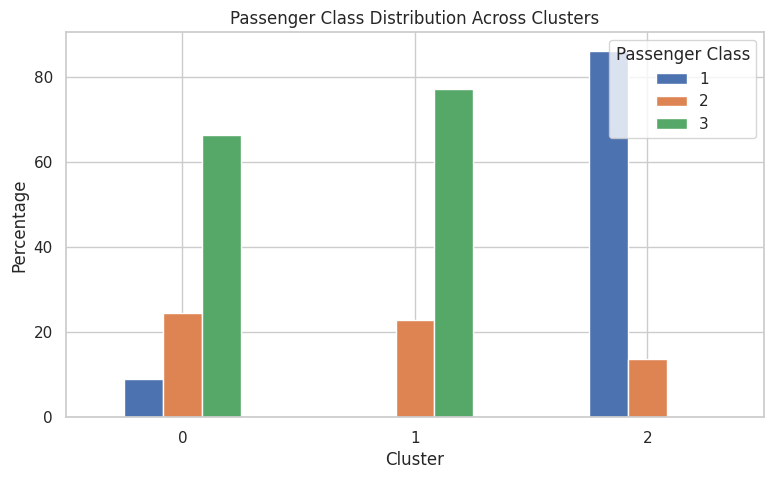

In [31]:
class_cluster.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Passenger Class Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.legend(title="Passenger Class")

plt.xticks(rotation=0)

plt.show()

In [32]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)

PCA explained variance ratio:
[0.33960812 0.32520788]


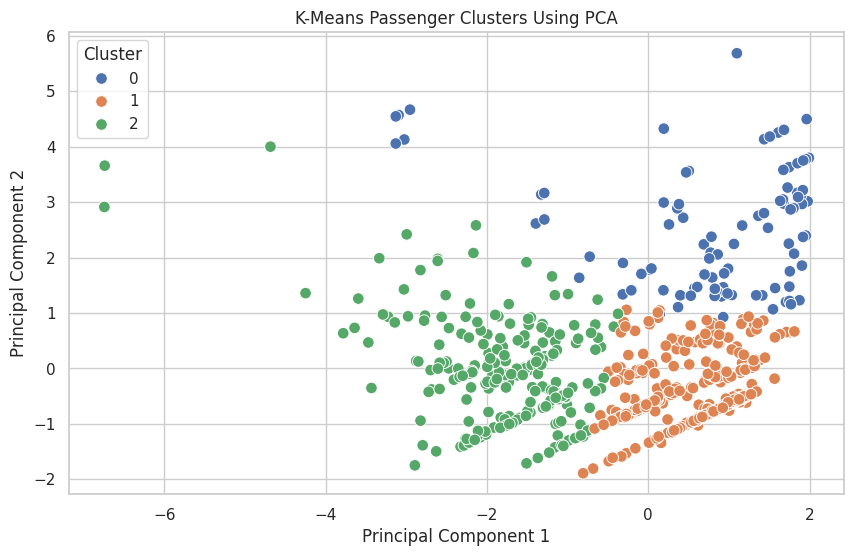

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="deep",
    s=70
)

plt.title("K-Means Passenger Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [34]:
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    cluster_centers,
    columns=features
)

centers_df.index.name = "Cluster"

print("Cluster Centers in Original Feature Scale:")
display(centers_df)

Cluster Centers in Original Feature Scale:


,pclass,age,sibsp,parch,fare
Cluster,,,,,
0,2.572727,15.088636,2.336364,1.936364,45.921856
1,2.771218,27.788598,0.225092,0.110701,12.191819
2,1.138075,39.497908,0.364017,0.280335,71.274390


In [35]:
for cluster in sorted(df_clustered["Cluster"].unique()):

    cluster_data_current = df_clustered[
        df_clustered["Cluster"] == cluster
    ]

    print("=" * 60)
    print(f"CLUSTER {cluster}")
    print("=" * 60)

    print("Number of passengers:",
          len(cluster_data_current))

    print("Average age:",
          round(cluster_data_current["age"].mean(), 2))

    print("Average fare:",
          round(cluster_data_current["fare"].mean(), 2))

    print("Average passenger class:",
          round(cluster_data_current["pclass"].mean(), 2))

    print("Average siblings/spouses:",
          round(cluster_data_current["sibsp"].mean(), 2))

    print("Average parents/children:",
          round(cluster_data_current["parch"].mean(), 2))

    print("Survival rate:",
          round(cluster_data_current["survived"].mean() * 100, 2),
          "%")

    print()

CLUSTER 0
Number of passengers: 110
Average age: 13.36
Average fare: 45.92
Average passenger class: 2.57
Average siblings/spouses: 2.34
Average parents/children: 1.94
Survival rate: 45.45 %

CLUSTER 1
Number of passengers: 542
Average age: 27.72
Average fare: 12.19
Average passenger class: 2.77
Average siblings/spouses: 0.23
Average parents/children: 0.11
Survival rate: 28.41 %

CLUSTER 2
Number of passengers: 239
Average age: 41.15
Average fare: 71.27
Average passenger class: 1.14
Average siblings/spouses: 0.36
Average parents/children: 0.28
Survival rate: 57.74 %



In [36]:
final_cluster_summary = df_clustered.groupby("Cluster").agg(
    Passenger_Count=("Cluster", "size"),
    Average_Age=("age", "mean"),
    Average_Fare=("fare", "mean"),
    Average_Class=("pclass", "mean"),
    Average_Siblings_Spouses=("sibsp", "mean"),
    Average_Parents_Children=("parch", "mean"),
    Survival_Rate=("survived", "mean")
)

final_cluster_summary["Survival_Rate"] *= 100

final_cluster_summary = final_cluster_summary.round(2)

display(final_cluster_summary)

,Passenger_Count,Average_Age,Average_Fare,Average_Class,Average_Siblings_Spouses,Average_Parents_Children,Survival_Rate
Cluster,,,,,,,
0,110,13.36,45.92,2.57,2.34,1.94,45.45
1,542,27.72,12.19,2.77,0.23,0.11,28.41
2,239,41.15,71.27,1.14,0.36,0.28,57.74


In [37]:
final_silhouette = silhouette_score(
    scaled_data,
    cluster_labels
)

print(
    "Final Silhouette Score:",
    round(final_silhouette, 4)
)

Final Silhouette Score: 0.417


In [38]:
df_clustered.to_csv(
    "titanic_clustered.csv",
    index=False
)

print("Clustered dataset saved as titanic_clustered.csv")

Clustered dataset saved as titanic_clustered.csv


In [39]:
from google.colab import files

files.download("titanic_clustered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
print("""
WEEK 3 CONCLUSION

K-Means clustering was applied to the Titanic passenger dataset
using passenger class, age, family-related variables, and fare.

The features were preprocessed and standardized before clustering.
The Elbow Method and Silhouette Score were used to evaluate different
cluster configurations.

The resulting clusters represent groups of passengers with similar
characteristics based on the selected features. Cluster summaries,
survival rates, gender distribution, passenger class distribution,
and PCA visualization were used to interpret the groups.

This analysis demonstrates how unsupervised learning can identify
hidden patterns and segments in a dataset without using a target
variable during cluster formation.

The resulting passenger segments can be useful for understanding
different groups within the dataset and demonstrate the practical
application of K-Means clustering in data science.
""")


WEEK 3 CONCLUSION

K-Means clustering was applied to the Titanic passenger dataset
using passenger class, age, family-related variables, and fare.

The features were preprocessed and standardized before clustering.
The Elbow Method and Silhouette Score were used to evaluate different
cluster configurations.

The resulting clusters represent groups of passengers with similar
characteristics based on the selected features. Cluster summaries,
survival rates, gender distribution, passenger class distribution,
and PCA visualization were used to interpret the groups.

This analysis demonstrates how unsupervised learning can identify
hidden patterns and segments in a dataset without using a target
variable during cluster formation.

The resulting passenger segments can be useful for understanding
different groups within the dataset and demonstrate the practical
application of K-Means clustering in data science.

